In [23]:
# End-to-End Machine Learning Pipeline Assignment using MySQL and Streamlit for Titanic Dataset
# Step 1: Setup and Data Preparation
# Install and Import Necessary Libraries

!pip install pandas numpy scikit-learn xgboost streamlit sqlalchemy pymysql


In [24]:
# Step 2: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pickle

In [25]:
# Step 3: Establishing a connection for MySQL and Data Download from MySQL to Jupyter Notebook:
import pymysql
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

try:
    # Establish the connection
    conn = pymysql.connect(
        host = '127.0.0.1',
        user = 'root',
        password = 'Vizag!23', # Give your own MySQL password here
        port = 3306
    )

    # Load data into DataFrame
    query = "SELECT * FROM titanic.titanic"
    df = pd.read_sql(query, conn)
    print("Data downloaded from MySQL successfully!")

    # Display the results
    print('Connection successful. Here is your data :')
    
    print("\nFirst 5 rows of the DataFrame:")
    print(df.head())
    print("\nDataFrame information:")
    print(df.info())

except pymysql.Error as e:
    print(f"MySQL Error : {e}")

finally:
    if 'conn' in locals():
        conn.close()
        print('Connection closed succesfully !!!')

Data downloaded from MySQL successfully!
Connection successful. Here is your data :

First 5 rows of the DataFrame:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex  Age  SibSp  \
0                            Braund, Mr. Owen Harris    male   22      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female   38      1   
2                             Heikkinen, Miss. Laina  female   26      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female   35      1   
4                           Allen, Mr. William Henry    male   35      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500              S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250              S 

In [26]:
# Check the data types of all columns
print(df.dtypes)

# Check if any columns have string values that might still be causing the issue
print(df.select_dtypes(include=['object']).columns)


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age              int64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')


Missing data analysis:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

After encoding:
   Sex  Embarked
0    1         3
1    0         1
2    0         3
3    0         3
4    1         3

Numeric columns used for correlation:
   PassengerId  Survived  Pclass  Age  SibSp  Parch     Fare
0            1         0       3   22      1      0   7.2500
1            2         1       1   38      1      0  71.2833
2            3         1       3   26      0      0   7.9250
3            4         1       1   35      1      0  53.1000
4            5         0       3   35      0      0   8.0500

Correlation matrix:
             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000  0.029340 -0.035349  0.036531 -0.082398 -0.011617   
Survived        0.029340  1.000000 -0.359653 -0.077729 -0.0

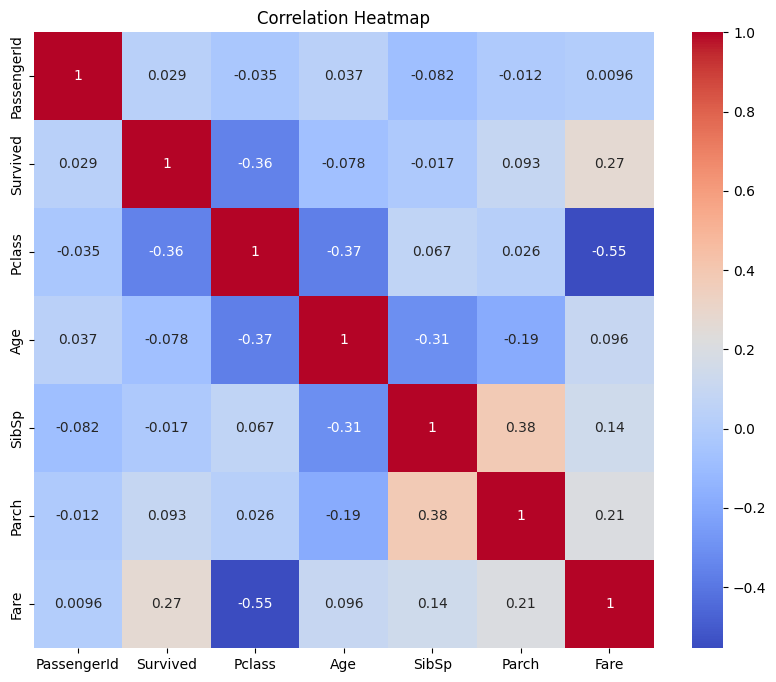

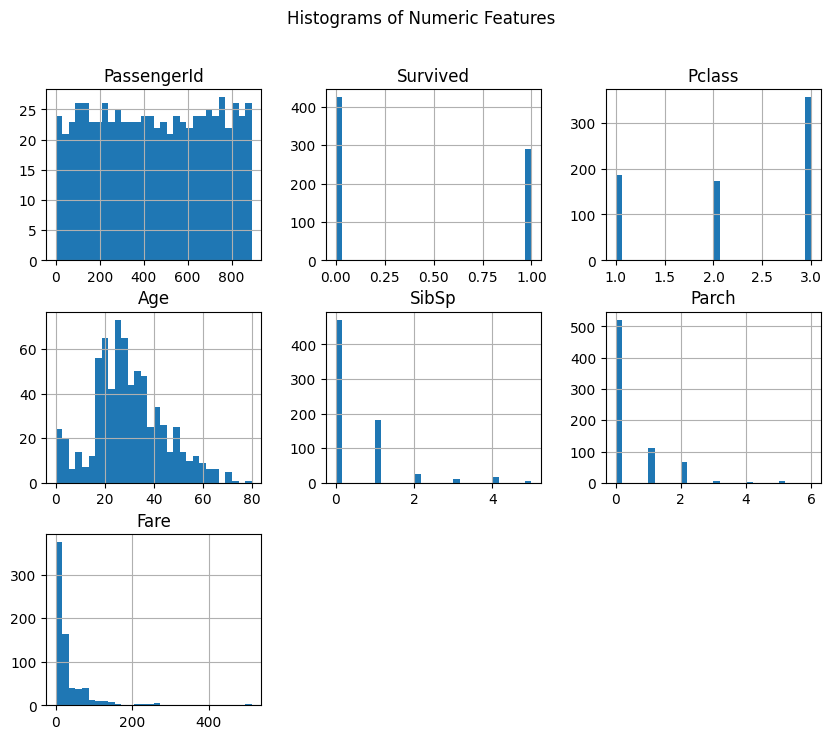

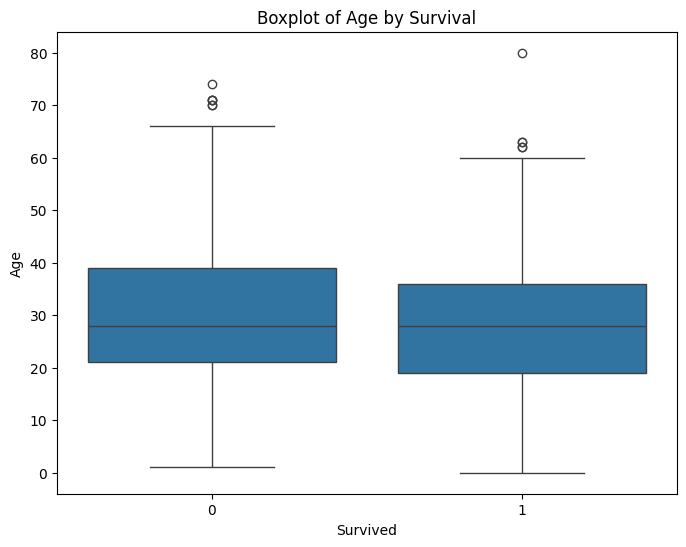

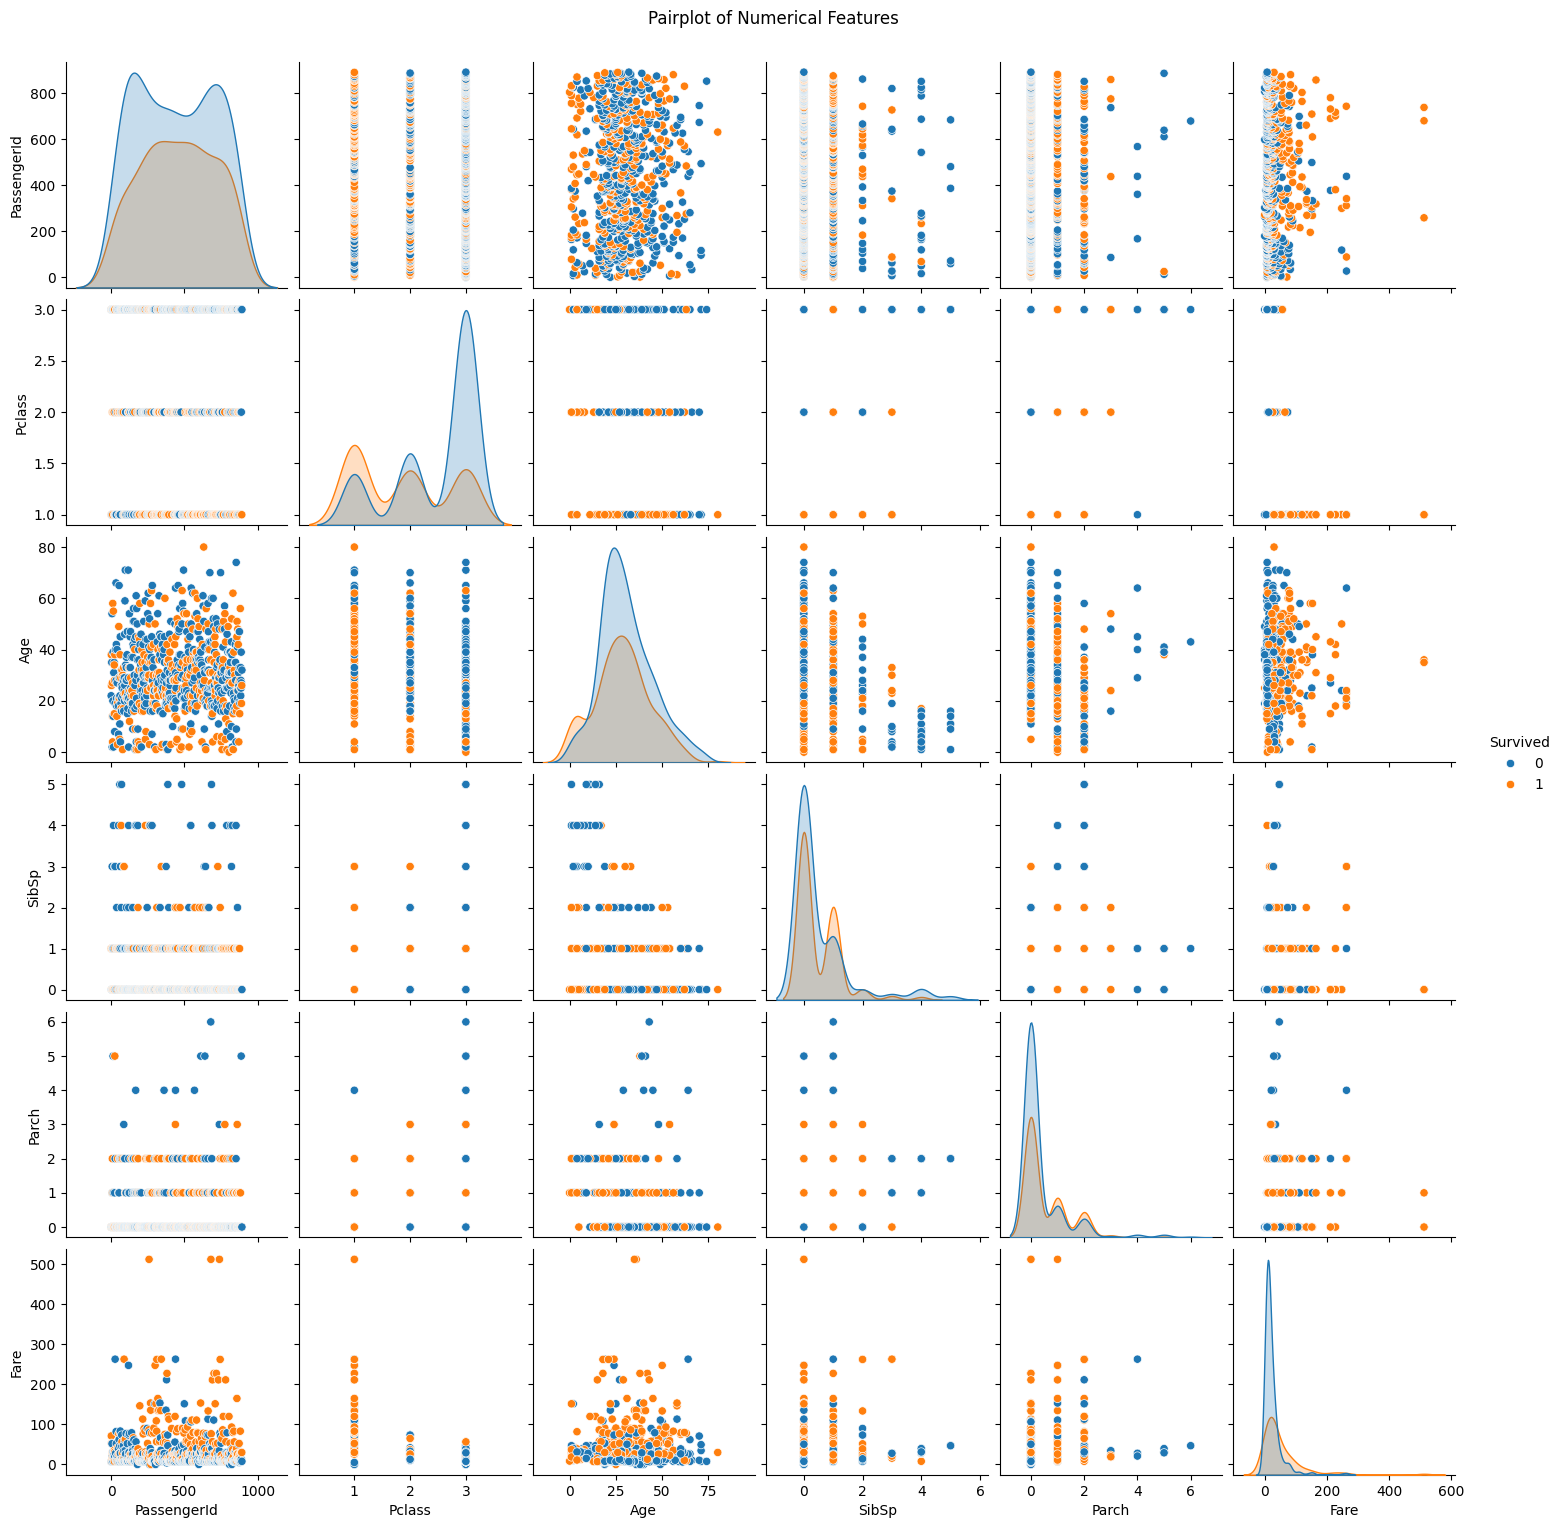

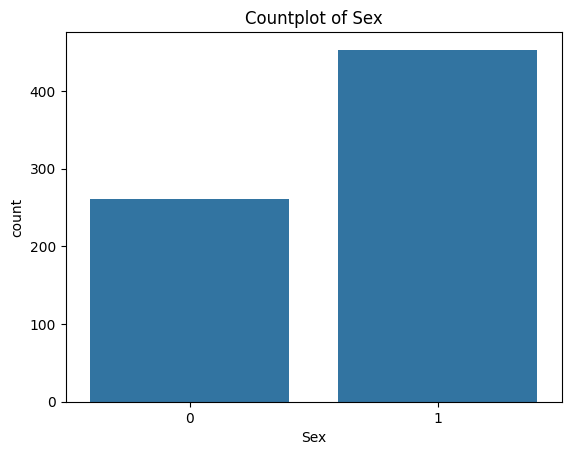

In [27]:
# Step 4: Exploratory Data Analysis (EDA)
# Perform some basic EDA on the Titanic dataset:

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# EDA: Missing data analysis
print("Missing data analysis:")
print(df.isnull().sum())

# Fill missing values (e.g., for 'Age' and 'Embarked')
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Label encoding for categorical variables like 'Sex' and 'Embarked'
label_encoder = LabelEncoder()
df['Sex'] = label_encoder.fit_transform(df['Sex'])  # 'Male' = 1, 'Female' = 0
df['Embarked'] = label_encoder.fit_transform(df['Embarked'].fillna('S'))  # Encoding 'S', 'C', 'Q'

# Check after encoding
print("\nAfter encoding:")
print(df[['Sex', 'Embarked']].head())

# Drop non-numeric columns that cannot be used for correlation
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Check numeric columns used for correlation
print("\nNumeric columns used for correlation:")
print(df_numeric.head())

# Calculate correlation and plot heatmap
corr = df_numeric.corr()  # This will calculate correlation only for numeric columns
print("\nCorrelation matrix:")
print(corr)

# Generate heatmap for the correlation
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()  # Force display and block further execution until the plot is closed

# Generate histograms for numeric features
df_numeric.hist(bins=30, figsize=(10, 8))
plt.suptitle('Histograms of Numeric Features')
plt.show()  # Force display and block further execution until the plot is closed

# Generate Boxplot for 'Age'
plt.figure(figsize=(8, 6))
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Boxplot of Age by Survival')
plt.show()  # Force display and block further execution until the plot is closed

# Generate Pairplot for numerical features
sns.pairplot(df_numeric, hue='Survived')
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()  # Force display and block further execution until the plot is closed

# Generate Countplot for categorical data 'Sex'
sns.countplot(x='Sex', data=df)
plt.title('Countplot of Sex')
plt.show()  # Force display and block further execution until the plot is closed



In [28]:
# Step 5: Model Building with Random Forest and XGBoost
# Model Building
# Train both Random Forest and XGBoost models:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Assuming your data is loaded into 'df'
# Define features (X) and target (y)
X = df.drop(columns=['Survived', 'Name', 'Ticket', 'Cabin', 'PassengerId'])  # Dropping non-numeric or unnecessary columns
y = df['Survived']  # Target variable

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Train XGBoost model
xgb_model = XGBClassifier(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict using both models
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

# Evaluate models
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

# Confusion Matrix for Random Forest
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

# Confusion Matrix for XGBoost
print("XGBoost Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))


Random Forest Accuracy: 0.7692307692307693
XGBoost Accuracy: 0.7902097902097902
Random Forest Confusion Matrix:
[[73 14]
 [19 37]]
XGBoost Confusion Matrix:
[[74 13]
 [17 39]]


In [29]:
# Step 6: Save the Trained Models (Pickle)
# Save both models using pickle:

import pickle

# Save Random Forest model
with open('random_forest_model_titanic.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save XGBoost model
with open('xgboost_model_titanic.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)


In [30]:
# Step 7: Streamlit App Development
# Create the app.py file for Streamlit to accept user input and display predictions.

import pickle
import numpy as np
import streamlit as st

# Load Random Forest and XGBoost models
@st.cache_resource
def load_rf_model():
    with open('random_forest_model_titanic.pkl', 'rb') as f:
        return pickle.load(f)

@st.cache_resource
def load_xgb_model():
    with open('xgboost_model_titanic.pkl', 'rb') as f:
        return pickle.load(f)

# Streamlit app
st.title("Titanic Survival Prediction App")

# Model selection
model_option = st.selectbox("Select Model", ["Random Forest", "XGBoost"])

# Input fields
pclass = st.selectbox("Passenger Class", [1, 2, 3])
sex = st.selectbox("Sex", ["male", "female"])
age = st.number_input("Age", min_value=0.0, step=1.0)
sibsp = st.number_input("Number of Siblings/Spouses Aboard", min_value=0)
parch = st.number_input("Number of Parents/Children Aboard", min_value=0)
fare = st.number_input("Fare", min_value=0.0)
embarked = st.selectbox("Embarked", ["C", "Q", "S"])

# Prediction button and logic
if st.button("Predict"):
    input_data = np.array([[pclass, sex, age, sibsp, parch, fare, embarked]])

    input_df = pd.DataFrame(input_data, columns=['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'])
    # Preprocessing the input data here, encode 'Sex' and 'Embarked' and handle missing values if necessary

    # Load the selected model and make prediction
    if model_option == "Random Forest":
        model = load_rf_model()
    else:
        model = load_xgb_model()

    prediction = model.predict(input_df)
    
    if prediction[0] == 1:
        st.write("The passenger survived!")
    else:
        st.write("The passenger did not survive.")


2025-05-01 02:13:02.200 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 02:13:02.201 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 02:13:02.201 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 02:13:02.201 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 02:13:02.204 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 02:13:02.206 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 02:13:02.206 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 02:13:02.206 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar